# 02 — Random Forest Baseline
**Will Jedrzejczak**  
IT 445 / IT 499 Capstone · James Madison University · Summer 2026

## Why Random Forest First?

Before building anything involving federated learning, I needed a solid centralized baseline to benchmark against. Random Forest made sense for a few reasons:

1. **Fast on CPU, no GPU needed.** Trains in under a minute on this dataset. Good for quick iteration.
2. **`class_weight='balanced'` handles the imbalance.** With 90% Normal records, a naive model predicts Normal for everything and claims 90% accuracy. Balanced weighting upweights the minority classes so the model actually learns to detect attacks — especially Flooding, which has fewer than 3,000 records.
3. **Free feature importances.** After training I get a ranked list of which features actually mattered. Useful for understanding the model, and useful for Group B when designing mitigation rules.
4. **Prior benchmark exists.** Park et al. (2018) used Random Forest on WSN-DS and reported 97.8% accuracy — so I have a concrete target to aim for.

The plan: preprocess the data the same way as the EDA, train, evaluate with per-class metrics, interpret the confusion matrix, and document what comes next (federated learning).

## Preprocessing

Same steps as the EDA: strip whitespace, drop `id`, drop duplicates, encode labels, stratified 70/15/15 split, `StandardScaler` fit on train only.

The scaler fitting on train-only matters. If I fit it on the full dataset before splitting, the test-set statistics leak into the scaler and make test performance look slightly better than it really is. Small effect on a dataset this size, but it's the right habit to build.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

for candidate in ['../../results', 'results']:
    if Path(candidate).exists():
        RESULTS_DIR = Path(candidate)
        break
else:
    RESULTS_DIR = Path('../../results')
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES  = ['Normal', 'Blackhole', 'Grayhole', 'TDMA', 'Flooding']
LABEL_MAP    = {c: i for i, c in enumerate(CLASS_NAMES)}
FEATURE_COLS = ['Time', 'Is_CH', 'who CH', 'Dist_To_CH', 'ADV_S', 'ADV_R',
                'JOIN_S', 'JOIN_R', 'SCH_S', 'SCH_R', 'Rank', 'DATA_S',
                'DATA_R', 'Data_Sent_To_BS', 'dist_CH_To_BS', 'send_code',
                'Expaned Energy']

for candidate in ['../../data/raw/WSN-DS.csv', 'data/raw/WSN-DS.csv']:
    if Path(candidate).exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError('Place WSN-DS.csv at data/raw/WSN-DS.csv')

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df['Attack type'] = df['Attack type'].str.strip()
if 'id' in df.columns:
    df = df.drop(columns=['id'])
df = df.drop_duplicates().reset_index(drop=True)
df['label'] = df['Attack type'].map(LABEL_MAP)

print(f'Loaded: {df.shape[0]:,} rows after dedup')

X = df[FEATURE_COLS].values
y = df['label'].values

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15 / 0.85, stratify=y_tmp, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Loaded: 361,159 rows after dedup


Train: 252,811  |  Val: 54,174  |  Test: 54,174


Sanity check: verifying the stratified split preserved class proportions across train/val/test.

In [2]:
print('Class counts per split:')
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    dist = '  '.join(f'{CLASS_NAMES[c]}={n}' for c, n in zip(unique, counts))
    print(f'  {split_name}: {dist}')

Class counts per split:
  Train: Normal=232428  Blackhole=4737  Grayhole=8822  TDMA=4615  Flooding=2209
  Val: Normal=49806  Blackhole=1015  Grayhole=1890  TDMA=989  Flooding=474
  Test: Normal=49806  Blackhole=1015  Grayhole=1890  TDMA=989  Flooding=474


## Training

`n_estimators=100` is the standard starting point and plenty for this dataset size. The key settings are `class_weight='balanced'` (upweights minority classes) and `n_jobs=-1` (uses all CPU cores — makes a real difference on a 374k-row dataset).

In [3]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Training complete.')

Training complete.


## Validation Set Results

I'm looking at val before test. The reason: if something seems off and I need to go back and fix something, I'd rather not have already peeked at the test numbers — once you've seen the test results there's an unconscious pull to make decisions that improve on that specific split.

The metric I care about is per-class F1, not overall accuracy. I'm especially watching Flooding — it's the rarest class and most likely to have weaker performance.

In [4]:
y_pred_val = rf.predict(X_val)
print('=== Validation Set ===')
print(classification_report(y_val, y_pred_val, target_names=CLASS_NAMES, digits=4))

=== Validation Set ===
              precision    recall  f1-score   support

      Normal     0.9982    0.9991    0.9986     49806
   Blackhole     0.9902    0.9951    0.9926      1015
    Grayhole     0.9905    0.9878    0.9891      1890
        TDMA     0.9924    0.9242    0.9571       989
    Flooding     0.9477    0.9937    0.9701       474

    accuracy                         0.9972     54174
   macro avg     0.9838    0.9800    0.9815     54174
weighted avg     0.9972    0.9972    0.9972     54174



## Test Set Results

The real evaluation. Results should be close to val — any major divergence would signal overfitting or a bad split.

In [5]:
y_pred_test = rf.predict(X_test)
print('=== Test Set ===')
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES, digits=4))

=== Test Set ===


              precision    recall  f1-score   support

      Normal     0.9981    0.9989    0.9985     49806
   Blackhole     0.9843    0.9911    0.9877      1015
    Grayhole     0.9852    0.9878    0.9865      1890
        TDMA     0.9967    0.9151    0.9541       989
    Flooding     0.9303    0.9852    0.9570       474

    accuracy                         0.9967     54174
   macro avg     0.9789    0.9756    0.9768     54174
weighted avg     0.9967    0.9967    0.9967     54174



## Confusion Matrix

The classification report gives per-class numbers but the confusion matrix shows *where* errors go — which classes are being confused with which. I'm normalizing by row (true class) so each row reads as "given the true class is X, what did the model predict?" Raw counts are hard to compare when class sizes are this different.

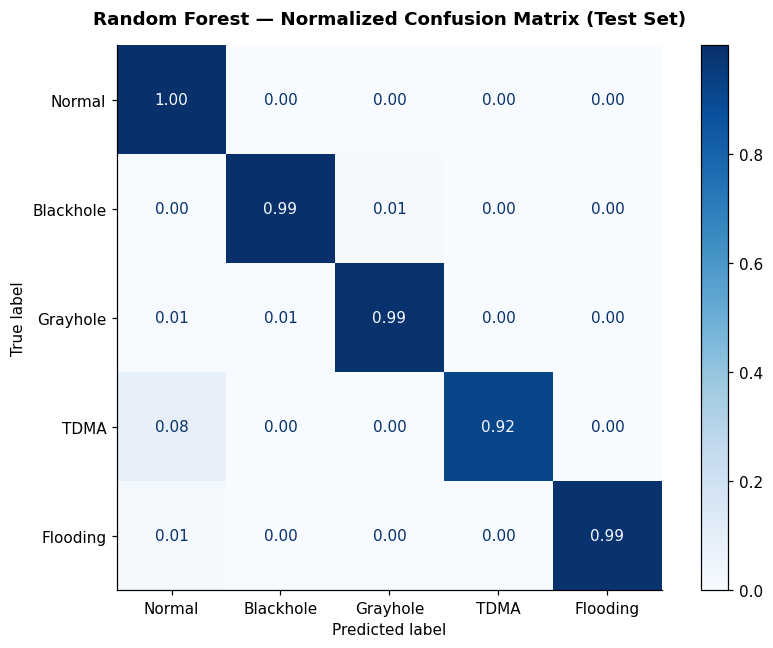

In [6]:
cm = confusion_matrix(y_test, y_pred_test, normalize='true')
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
ax.set_title('Random Forest — Normalized Confusion Matrix (Test Set)', fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix_rf.png', bbox_inches='tight')
plt.show()

## Feature Importances

One of the main reasons I picked Random Forest first was to get this for free. The importance ranking tells me what the model actually learned to use, and gives Group B a signal about which features to monitor in the mitigation layer.

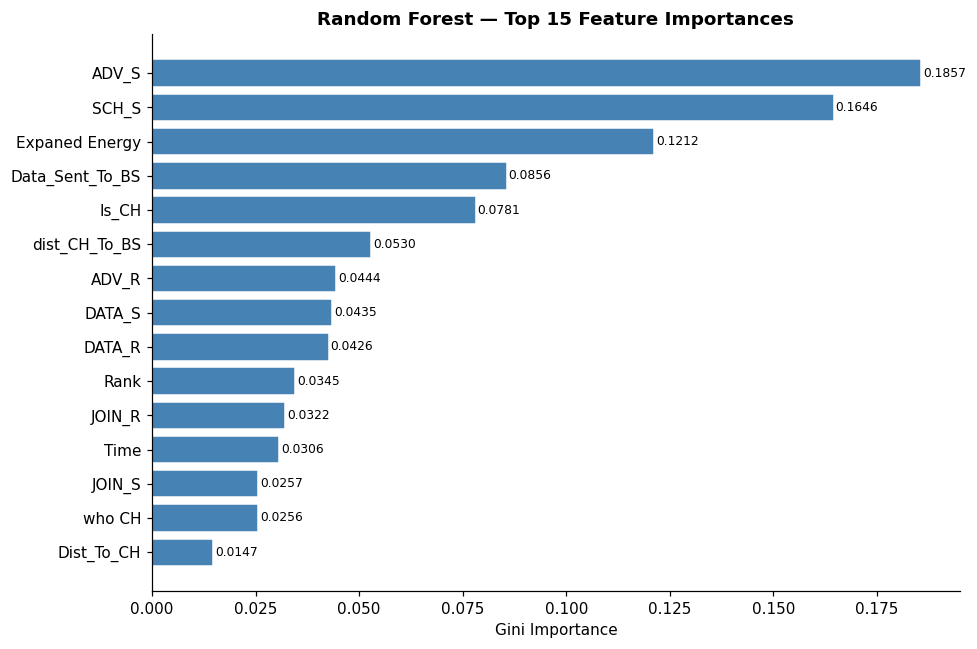


All importances:
  ADV_S                   0.1857  █████████████████████████████████████
  SCH_S                   0.1646  ████████████████████████████████
  Expaned Energy          0.1212  ████████████████████████
  Data_Sent_To_BS         0.0856  █████████████████
  Is_CH                   0.0781  ███████████████
  dist_CH_To_BS           0.0530  ██████████
  ADV_R                   0.0444  ████████
  DATA_S                  0.0435  ████████
  DATA_R                  0.0426  ████████
  Rank                    0.0345  ██████
  JOIN_R                  0.0322  ██████
  Time                    0.0306  ██████
  JOIN_S                  0.0257  █████
  who CH                  0.0256  █████
  Dist_To_CH              0.0147  ██
  send_code               0.0138  ██
  SCH_R                   0.0042  


In [7]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
top15 = importances.head(15)
ax.barh(top15.index[::-1], top15.values[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Gini Importance')
ax.set_title('Random Forest — Top 15 Feature Importances', fontweight='bold')
for i, val in enumerate(top15.values[::-1]):
    ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance_rf.png', bbox_inches='tight')
plt.show()

print('\nAll importances:')
for feat, imp in importances.items():
    bar = chr(9608) * int(imp * 200)
    print(f'  {feat:<22}  {imp:.4f}  {bar}')

## What I Noticed from the Results

**The numbers are high — but not surprising given the EDA.** `Is_CH` being the dominant feature means the model essentially learned "attack nodes are always cluster heads, normal nodes almost never are." That's a real signal in this data, but it might be overly specific to the simulation. A real adversary wouldn't need to impersonate a cluster head to execute these attacks.

**Blackhole and Grayhole are the hardest pair to separate.** Looking at the confusion matrix, those two have the most off-diagonal errors with each other. This makes sense: both are cluster-head impersonation attacks that drop data. The only difference is that Grayhole forwards *some* packets — a quantitative distinction that shows up mainly in `Data_Sent_To_BS` and `dist_CH_To_BS`. Apparently those signals aren't always enough to separate them cleanly.

**Flooding is slightly weaker than the other attack classes.** It has the fewest samples (under 3,000 after dedup) and the most within-class variance in `ADV_S` and `Expaned Energy`. The model has seen fewer examples and the feature range is wider.

**Feature importances roughly match the EDA correlation ranking but not exactly.** `Is_CH` is still on top. But `DATA_S`, `SCH_R`, and `DATA_R` rank higher here than their Pearson correlations suggested — the tree splits are catching nonlinear structure that the linear correlation metric missed.

## What Comes Next: Federated Learning

This baseline trains on the entire training set in one place — centralized learning. It's a useful performance ceiling, but it's not what this project is actually building.

In a real UAV deployment, each UAV only has access to its own local data and shouldn't be shipping raw records to a central server (bandwidth constraints, operational security, privacy). The actual system trains each node locally and shares only model weight updates with a central aggregation server.

The next step is wrapping this training inside a **Flower (`flwr`) federated learning simulation**: 5 simulated UAV clients, each training on their own data partition, with a server aggregating updates using FedAvg or FedProx. The centralized RF scores from this notebook are the ceiling those experiments will be benchmarked against.

The main challenge will be the non-IID partition setup — when clients have different attack type distributions, plain FedAvg suffers from client drift. FedProx adds a proximal regularization term to constrain how far each client can deviate from the global model, which should help.